# **Recommendation System using Cosine Similarity**

The Objective is to build a recommendation system that recommends similar anime based on features like genre, type, episodes, rating, and members using cosine similarity.

# **Importing Required Libraries**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# **Loading the Dataset**

In [2]:
df =pd.read_csv('/content/drive/MyDrive/ASSIGNMENTS/REcommendation System/anime.csv')

In [4]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


# **Exploring  the Dataset**

In [5]:
df.shape

(12294, 7)

In [6]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [7]:
df.dtypes

,0
anime_id,int64
name,object
genre,object
type,object
episodes,object
rating,float64
members,int64


In [8]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


Explanation:
This step helps us understand the structure of the dataset.The dataset contains information about different anime such as anime title, genre, type, episodes, rating, and members. This step helps us understand whether it conatins any  missing values or not .

# **Basic Statistics**

In [10]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


Explanation:
This gives basic statistical details of numerical columns.The describe function shows count, mean, minimum, maximum, and other statistical values for numerical columns like rating and members.

# **Handling the Missing Values**

In [11]:
data = df.copy()

# Fill missing genre and type
data["genre"] = data["genre"].fillna("Unknown")
data["type"] = data["type"].fillna("Unknown")

# Convert episodes to numeric
data["episodes"] = data["episodes"].replace("Unknown", np.nan)
data["episodes"] = pd.to_numeric(data["episodes"])

# Fill missing episodes with median
data["episodes"] = data["episodes"].fillna(data["episodes"].median())

# Fill missing rating with median
data["rating"] = data["rating"].fillna(data["rating"].median())

print("Missing values after handling:")
print(data.isnull().sum())

Missing values after handling:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


Explanation:
Missing values can create problems during model building. Missing values in categorical columns were replaced with Unknown. Missing numerical values in rating and episodes were filled using median values. Median is used because it is less affected by extreme values.

# **Checking Anime Type Distribution**

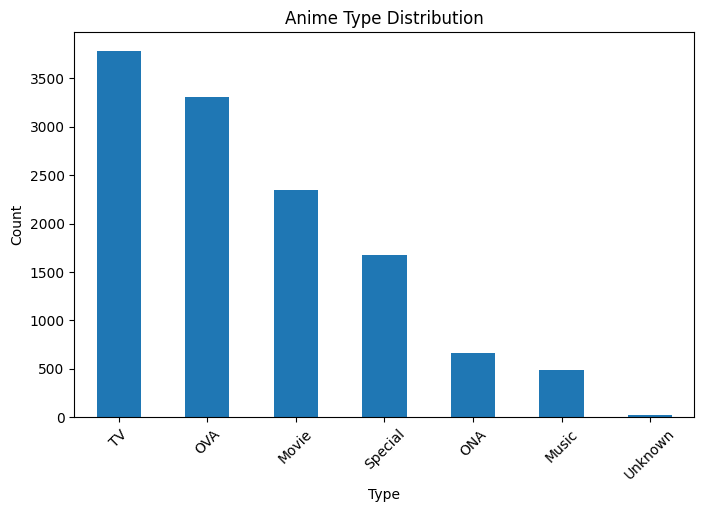

In [12]:
data["type"].value_counts().plot(kind="bar", figsize=(8, 5))

plt.title("Anime Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Explanation:
This shows how many anime belong to each type like TV, Movie, OVA, etc.The bar chart shows the distribution of anime based on type. It helps us understand which type of anime appears more frequently in the dataset.

# **Rating Distribution**

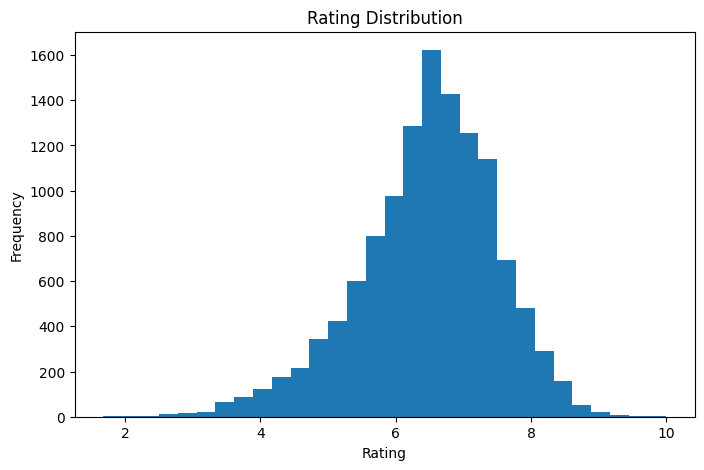

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(data["rating"], bins=30)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Explanation:
This histogram shows how anime ratings are distributed. It helps us understand the range where most ratings are present.

# **Members Distribution**

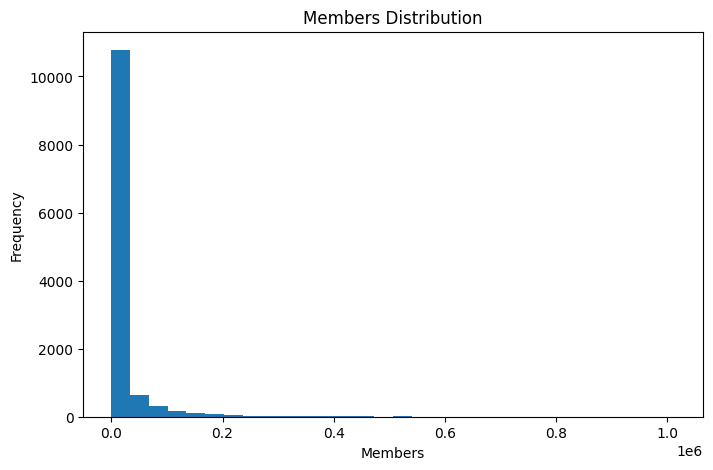

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(data["members"], bins=30)

plt.title("Members Distribution")
plt.xlabel("Members")
plt.ylabel("Frequency")
plt.show()

Explanation:
This histogram shows how community members are distributed.Some anime may have very high members compared to others.

# **Top 10 Anime by Rating**

In [16]:
top_rated = data.sort_values(by="rating", ascending=False).head(10)

top_rated[["name", "genre", "type", "episodes", "rating", "members"]]

,name,genre,type,episodes,rating,members
10464,Taka no Tsume 8: Yoshida-kun no X-Files,"Comedy, Parody",Movie,1.0,10.00,13
10400,Spoon-hime no Swing Kitchen,"Adventure, Kids",TV,2.0,9.60,47
9595,Mogura no Motoro,Slice of Life,Movie,1.0,9.50,62
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
9078,Kahei no Umi,Historical,Movie,1.0,9.33,44
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
10786,Yakusoku: Africa Mizu to Midori,"Drama, Kids",OVA,1.0,9.25,53
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


Explanation:
This table shows the top 10 anime based on rating. These anime have the highest average rating in the dataset.

# **Top 10 Anime by Members**

In [17]:
top_members = data.sort_values(by="members", ascending=False).head(10)

top_members[["name", "genre", "type", "episodes", "rating", "members"]]

,name,genre,type,episodes,rating,members
40,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37.0,8.71,1013917
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13.0,8.39,717796
19,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,25.0,8.83,715151
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220.0,7.81,683297
3,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26.0,8.07,657190
131,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25.0,8.45,633817


This table shows anime with the highest number of community members. It helps us identify popular anime.

# **Feature Extraction Process**

We will use these features:
genre,
type,
episodes,
rating,
members.

# **Converting Genre into Numerical Form**

In [18]:
# Split genre values
genre_list = data["genre"].apply(lambda x: x.split(", "))

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(genre_list)

genre_df = pd.DataFrame(
    genre_encoded,
    columns=mlb.classes_,
    index=data.index
)

genre_df.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Since genre is categorical text data, it is converted into numerical form. Each genre becomes a separate column with values 0 or 1.

# **Converting Type into Numerical Form**

In [19]:
type_df = pd.get_dummies(data["type"], prefix="type")

type_df.head()

,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown
0,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False


The type column contains categories like TV, Movie, OVA, etc. One-hot encoding converts these categories into numerical columns.

# **Normalize Numerical Features**

In [20]:
num_features = data[["episodes", "rating", "members"]]

scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(num_features)

num_df = pd.DataFrame(
    num_scaled,
    columns=["episodes_scaled", "rating_scaled", "members_scaled"],
    index=data.index
)

num_df.head()

,episodes_scaled,rating_scaled,members_scaled
0,0.000000,0.924370,0.197872
1,0.034673,0.911164,0.782770
2,0.027518,0.909964,0.112689
3,0.012658,0.900360,0.664325
4,0.027518,0.899160,0.149186


Explanation:
Episodes, rating, and members have different scales. Normalization brings them into a similar range.Numerical features were normalized using MinMaxScaler. This keeps all values between 0 and 1, which helps cosine similarity work better.

# **Creating the Final Feature Matrix**

In [21]:
feature_matrix = pd.concat([genre_df, type_df, num_df], axis=1)

print("Final feature matrix shape:", feature_matrix.shape)

feature_matrix.head()

Final feature matrix shape: (12294, 54)


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown,episodes_scaled,rating_scaled,members_scaled
0,0,0,0,0,0,0,1,0,0,0,...,True,False,False,False,False,False,False,0.000000,0.924370,0.197872
1,1,1,0,0,0,0,1,0,1,0,...,False,False,False,False,False,True,False,0.034673,0.911164,0.782770
2,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.027518,0.909964,0.112689
3,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.012658,0.900360,0.664325
4,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.027518,0.899160,0.149186


Explanation:
Here i combine genre, type, and numerical features into one final feature matrix.The final feature matrix contains all selected features in numerical form. This matrix will be used to calculate similarity between anime.

# **Recommendation System**

Here I design a function that recommends anime based on cosine similarity.

**Compute Cosine Similarity**

In [22]:
cosine_sim = cosine_similarity(feature_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (12294, 12294)


Explanation:
Cosine similarity calculates similarity between anime based on selected features.The cosine similarity matrix stores similarity scores between each anime. A higher score means anime are more similar.

**Recommendation Function**

In [23]:
def recommend_anime(anime_name, top_n=10, threshold=0.3):
    # Find anime index
    matches = data[data["name"].str.lower() == anime_name.lower()]

    if matches.empty:
        return "Anime not found. Please check the spelling."

    anime_index = matches.index[0]

    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[anime_index]))

    # Sort by similarity score in descending order
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Remove the same anime and apply threshold
    recommendations = []

    for index, score in similarity_scores:
        if index != anime_index and score >= threshold:
            recommendations.append((index, score))

        if len(recommendations) == top_n:
            break

    # Create recommendation dataframe
    recommended_anime = []

    for index, score in recommendations:
        recommended_anime.append({
            "Anime Name": data.loc[index, "name"],
            "Genre": data.loc[index, "genre"],
            "Type": data.loc[index, "type"],
            "Episodes": data.loc[index, "episodes"],
            "Rating": data.loc[index, "rating"],
            "Members": data.loc[index, "members"],
            "Similarity Score": round(score, 4)
        })

    return pd.DataFrame(recommended_anime)

Explanation:
This function takes an anime name and recommends similar anime.

# **Testing  the Recommendation System**

In [24]:
recommend_anime("Naruto", top_n=10, threshold=0.3)

,Anime Name,Genre,Type,Episodes,Rating,Members,Similarity Score
0,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,2.0,7.94,533578,0.9974
1,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,203.0,8.37,258103,0.9120
2,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,291.0,8.32,375662,0.8730
3,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366.0,7.95,624055,0.8564
4,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,97.0,7.95,116832,0.8558
5,Dragon Ball Super,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,2.0,7.40,111443,0.8532
6,Medaka Box,"Action, Comedy, Ecchi, Martial Arts, School, S...",TV,12.0,7.21,110042,0.8525
7,Tenjou Tenge,"Action, Comedy, Ecchi, Martial Arts, School, S...",TV,24.0,7.10,103449,0.8518
8,Medaka Box Abnormal,"Action, Comedy, Ecchi, Martial Arts, School, S...",TV,12.0,7.63,66972,0.8505
9,Dragon Ball Kai (2014),"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,61.0,8.01,42666,0.8499


Explanation:
Now I test the recommendation system using one anime name.The recommendation system returns anime similar to the target anime. The similarity score shows how closely related the recommended anime is to the selected anime.

In [25]:
recommend_anime("Death Note", top_n=10, threshold=0.3)

,Anime Name,Genre,Type,Episodes,Rating,Members,Similarity Score
0,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,24.0,8.41,218101,0.8895
1,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",TV,13.0,7.74,137687,0.8847
2,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",TV,26.0,8.17,359494,0.8344
3,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",Special,2.0,7.84,88699,0.8034
4,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26.0,8.07,657190,0.8011
5,Jigoku Shoujo Mitsuganae,"Mystery, Psychological, Supernatural",TV,26.0,7.81,58993,0.7904
6,Yakushiji Ryouko no Kaiki Jikenbo,"Mystery, Police, Supernatural",TV,13.0,7.19,11002,0.7811
7,Saint Luminous Jogakuin,"Mystery, Psychological, Supernatural",TV,13.0,6.17,1701,0.7748
8,Boku dake ga Inai Machi,"Mystery, Psychological, Seinen, Supernatural",TV,12.0,8.65,402381,0.7593
9,Zankyou no Terror,"Psychological, Thriller",TV,11.0,8.26,342893,0.7459


The system recommends anime similar to Death Note based on genre, type, episodes, rating, and members.

# **Experiment with Different Threshold Values**

In [26]:
anime_name = "Naruto"
thresholds = [0.2, 0.4, 0.6, 0.8]

for t in thresholds:
    result = recommend_anime(anime_name, top_n=10, threshold=t)
    print("\nThreshold:", t)

    if isinstance(result, str):
        print(result)
    else:
        print("Number of recommendations:", len(result))
        display(result[["Anime Name", "Similarity Score"]])


Threshold: 0.2
Number of recommendations: 10


,Anime Name,Similarity Score
0,Naruto: Shippuuden,0.9974
1,Katekyo Hitman Reborn!,0.9120
2,Dragon Ball Z,0.8730
3,Bleach,0.8564
4,Dragon Ball Kai,0.8558
5,Dragon Ball Super,0.8532
6,Medaka Box,0.8525
7,Tenjou Tenge,0.8518
8,Medaka Box Abnormal,0.8505
9,Dragon Ball Kai (2014),0.8499



Threshold: 0.4
Number of recommendations: 10


,Anime Name,Similarity Score
0,Naruto: Shippuuden,0.9974
1,Katekyo Hitman Reborn!,0.9120
2,Dragon Ball Z,0.8730
3,Bleach,0.8564
4,Dragon Ball Kai,0.8558
5,Dragon Ball Super,0.8532
6,Medaka Box,0.8525
7,Tenjou Tenge,0.8518
8,Medaka Box Abnormal,0.8505
9,Dragon Ball Kai (2014),0.8499



Threshold: 0.6
Number of recommendations: 10


,Anime Name,Similarity Score
0,Naruto: Shippuuden,0.9974
1,Katekyo Hitman Reborn!,0.9120
2,Dragon Ball Z,0.8730
3,Bleach,0.8564
4,Dragon Ball Kai,0.8558
5,Dragon Ball Super,0.8532
6,Medaka Box,0.8525
7,Tenjou Tenge,0.8518
8,Medaka Box Abnormal,0.8505
9,Dragon Ball Kai (2014),0.8499



Threshold: 0.8
Number of recommendations: 10


,Anime Name,Similarity Score
0,Naruto: Shippuuden,0.9974
1,Katekyo Hitman Reborn!,0.9120
2,Dragon Ball Z,0.8730
3,Bleach,0.8564
4,Dragon Ball Kai,0.8558
5,Dragon Ball Super,0.8532
6,Medaka Box,0.8525
7,Tenjou Tenge,0.8518
8,Medaka Box Abnormal,0.8505
9,Dragon Ball Kai (2014),0.8499


When the threshold is low, more anime are recommended. When the threshold is high, only highly similar anime are recommended. So, threshold controls the strictness of recommendations.

# **Visualizing Recommendation Scores**

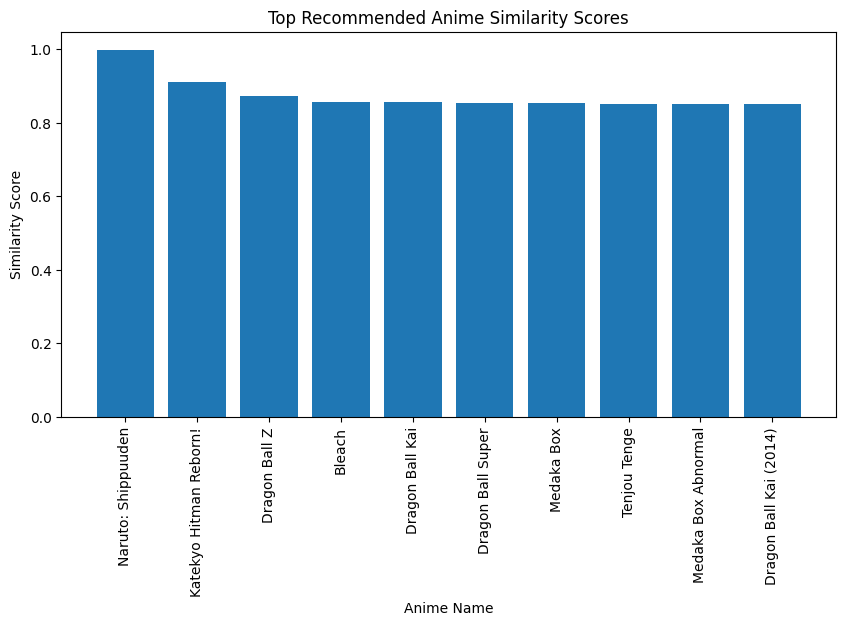

In [27]:
result = recommend_anime("Naruto", top_n=10, threshold=0.3)

plt.figure(figsize=(10, 5))
plt.bar(result["Anime Name"], result["Similarity Score"])

plt.title("Top Recommended Anime Similarity Scores")
plt.xlabel("Anime Name")
plt.ylabel("Similarity Score")
plt.xticks(rotation=90)
plt.show()

The bar graph shows similarity scores of recommended anime. Higher similarity score means the anime is more similar to the selected anime.

# **Final Analysis**

A recommendation system is built using cosine similarity on the anime dataset. First, the dataset was loaded and explored. Missing values were handled in genre, type, rating, and episodes columns. Categorical features like genre and type were converted into numerical form.

Numerical features such as episodes, rating, and members were normalized using MinMaxScaler. After preprocessing, all features were combined into one feature matrix. Cosine similarity was then used to calculate similarity between anime.

A recommendation function is created where the user gives an anime name, and the system returns similar anime based on similarity scores. Different threshold values were also tested. A lower threshold gives more recommendations, while a higher threshold gives fewer but more similar recommendations.

# **Performance Analysis**

The recommendation system performs well for finding anime with similar genres, type, rating, episodes, and popularity. Since it is based on item features, it does not require individual user history.

**There are some limitations:**
1. It does not use personal user preferences.
2. It depends on available anime features.
3. Similarity may not always match actual user taste.
4. Some missing values were filled, which may slightly affect results.

**Areas of Improvement**:
1. Add user rating history for better personalized recommendations.
2. Use collaborative filtering with user-anime ratings.
3. Use hybrid recommendation by combining content-based and collaborative filtering.
4. Add more features such as studio, release year, popularity rank, and reviews.
5. Improve text processing for genre and anime descriptions.